# Coexistence Phase Boundaries of A Binary Polymer Blend

We are considering a binary polymer blend consisting of AB diblock copolymers and A homopolymers, which is denoted as AB/A. The length of the AB diblock copolymer is $N$, the length of A block in the AB diblock copolymer is $fN$, the length of the A homopolymer is $\alpha N$, the volume fraction of the homopolymer is $\phi$, the Flory-Huggins interaction parameter is $\chi N$ between A and B monomers.

The free energy of a mixing homogeneous phase (DIS) is

$$
    F = \frac{F_c}{CV} = \chi N\phi_A\phi_B + (1-\phi)\left[ \ln C(1-\phi) - 1 \right] + \frac{\phi}{\alpha}\left( \ln \frac{C\phi}{\alpha} - 1 \right)
$$

with

$$
    \phi_A = (1-\phi)f + \phi \\
    \phi_B = 1 - \phi_A = (1-f)(1-\phi)
$$

In this study, we will set $C = 1$.

In [1]:
using PhaseDiagram
import Plots
using Plots: plot, plot!
using LaTeXStrings
using ArgCheck
using CubicHermiteSpline
using Test

In [2]:
Plots.default(size=(600, 370))
fntf = :Helvetica
titlefont = Plots.font(fntf, pointsize=12)
guidefont = Plots.font(fntf, pointsize=12)
tickfont = Plots.font(fntf, pointsize=9)
legendfont = Plots.font(fntf, pointsize=8)
Plots.default(fontfamily=fntf)
Plots.default(titlefont=titlefont, guidefont=guidefont, tickfont=tickfont, legendfont=legendfont)
Plots.default(minorticks=true)
Plots.default(linewidth=1.2)
Plots.default(foreground_color_legend=nothing)
Plots.default(legend=false)

In [32]:
function line(p1, p2, x=nothing)
    x1, y1 = p1
    x2, y2 = p2
    if isnothing(x)
        x = range(x1, x2, length=100)
    end
    k = (y2 - y1) / (x2 - x1)
    return @. k*(x-x1) + y1
end

line (generic function with 2 methods)

## DIS-DIS coexistence line

### Symmetric AB diblock copolymers

For symmetric AB diblock copolymers, we have $f=0.5$. We also assume the length of the homopolymer being $\alpha=1.0$. We can write the free energy of a DIS phase as

$$
    F = \frac{1}{4}\chi N(1-\phi^2) + (1-\phi)\ln (1-\phi) + \phi\ln\phi - 1
$$

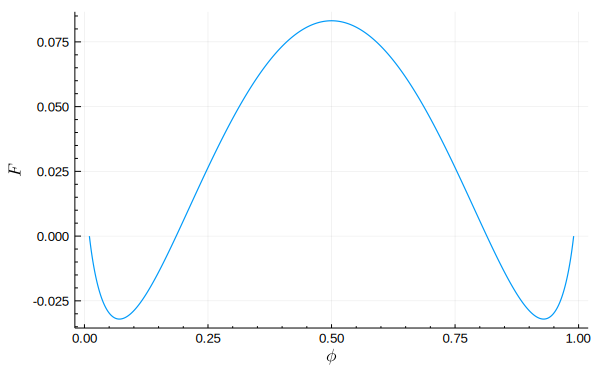

In [36]:
ϕ = range(0.01, 0.99, step=0.001);
xN = 12
F = @. 0.25 * xN * (1-ϕ^2) + (1-ϕ)*log(1-ϕ) + ϕ*log(ϕ) - 1;
Fr = line((ϕ[1], F[1]), (ϕ[end], F[end]), ϕ)
plot(ϕ, F .- Fr, xlabel=L"\phi", ylabel=L"F")

#### Analytical solution

In this situation,

#### Optimization approach with analytical expression for energy and chemical potential

(ϕc, χNc) = (0.5, 8.0)


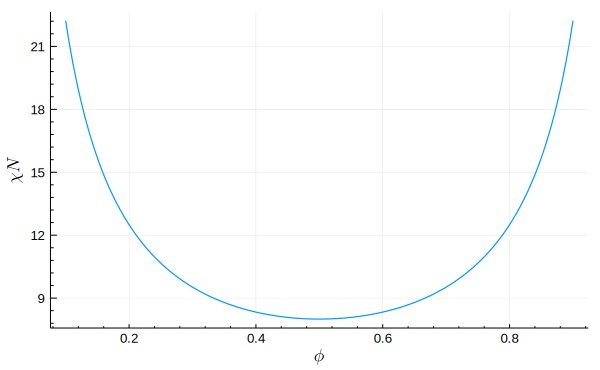

In [19]:
f = 0.5
α = 1.0
ϕc, χNc = critical_point(f, α)
@show ϕc, χNc
ϕ = range(0.1, 0.9, step=0.001);
χNs(ϕ) = spinodal(ϕParameter(), ϕ, f, α)
χNs_all = χNs.(ϕ);
xlab = L"\phi"
ylab = L"\chi N"
lab = L"f=$f, α=$α"
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label=lab)

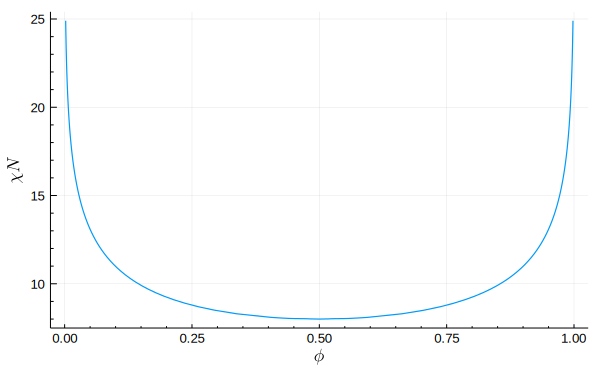

In [20]:
χN1 = range(χNc+0.1, 25, step=0.2);
χN2 = range(χNc+0.01, χNc+0.09, step=0.01)
χN = vcat(χN2, χN1)
# @show χN
ϕb(χN) = binodal(χN, f, α, 1.0)
ϕb_all = ϕb.(χN);
ϕb1 = [x[1] for x in ϕb_all];
ϕb2 = [x[2] for x in ϕb_all];
ϕb_sort = vcat(reverse(ϕb1), ϕc, ϕb2)
χN_sort = vcat(reverse(χN), χNc, χN)
io = open("/Users/lyx/Downloads/boundary_DIS_DIS.txt", "w")
println(io, "# phih    xN")
for i in eachindex(ϕb_sort)
    phi, xN = ϕb_sort[i], χN_sort[i]
    println(io, "$phi \t $xN")
end
close(io)
# plot(ϕb1, χN, xlabel=xlab, ylabel=ylab)
# plot!(ϕb2, χN, xlabel=xlab, ylabel=ylab)
plot(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab)

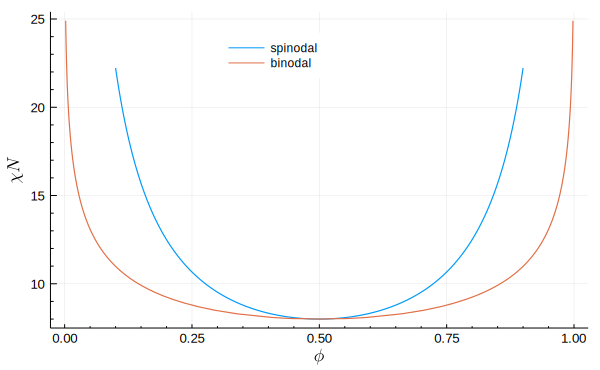

In [26]:
plot(ϕ, χNs_all, xlabel=xlab, ylabel=ylab, label="spinodal", legend=:top)
plot!(ϕb_sort, χN_sort, xlabel=xlab, ylabel=ylab, label="binodal")
# savefig("~/Downloads/chiN-phi-f0.5-alpha1.pdf")

### Solution by interpolation

In [29]:
? range

search: range LinRange UnitRange StepRange StepRangeLen trailing_zeros



```
range(start[, stop]; length, stop, step=1)
```

Given a starting value, construct a range either by length or from `start` to `stop`, optionally with a given step (defaults to 1, a [`UnitRange`](@ref)). One of `length` or `stop` is required.  If `length`, `stop`, and `step` are all specified, they must agree.

If `length` and `stop` are provided and `step` is not, the step size will be computed automatically such that there are `length` linearly spaced elements in the range (a [`LinRange`](@ref)).

If `step` and `stop` are provided and `length` is not, the overall range length will be computed automatically such that the elements are `step` spaced (a [`StepRange`](@ref)).

`stop` may be specified as either a positional or keyword argument.

!!! compat "Julia 1.1"
    `stop` as a positional argument requires at least Julia 1.1.


# Examples

```jldoctest
julia> range(1, length=100)
1:100

julia> range(1, stop=100)
1:100

julia> range(1, step=5, length=100)
1:5:496

julia> range(1, step=5, stop=100)
1:5:96

julia> range(1, 10, length=101)
1.0:0.09:10.0

julia> range(1, 100, step=5)
1:5:96
```

---

```
range(start::T; stop::T, length=100) where T<:Colorant
range(start::T, stop::T; length=100) where T<:Colorant
```

Generates N (=`length`) >2 colors in a linearly interpolated ramp from `start` to`stop`, inclusive, returning an `Array` of colors.

!!! compat "Julia 1.1"
    `stop` as a positional argument requires at least Julia 1.1.

